In [16]:
import shap
import joblib
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [4]:
xgb_fraud = joblib.load(r'C:\Users\bless\OneDrive\Desktop\week-8\fraud-detection-project\models\saved_models\fraud_xgboost.pkl')
fraud_df = pd.read_csv('../data/Fraud_Data.csv')
ip_df = pd.read_csv('../data/IpAddress_to_Country.csv')

In [5]:
fraud_df['ip_int'] = fraud_df['ip_address'].astype(int)
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(int)
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(int)

In [6]:
def find_country(ip):
    row = ip_df[(ip_df['lower_bound_ip_address'] <= ip) & (ip_df['upper_bound_ip_address'] >= ip)]
    return row['country'].values[0] if not row.empty else 'Unknown'

fraud_df['country'] = fraud_df['ip_int'].apply(find_country)
fraud_df['hour_of_day'] = pd.to_datetime(fraud_df['purchase_time']).dt.hour
fraud_df['day_of_week'] = pd.to_datetime(fraud_df['purchase_time']).dt.dayofweek
fraud_df['time_since_signup'] = (pd.to_datetime(fraud_df['purchase_time']) - pd.to_datetime(fraud_df['signup_time'])).dt.days
transaction_freq = fraud_df.groupby('user_id').size()
fraud_df['user_transaction_count'] = fraud_df['user_id'].map(transaction_freq)

In [7]:
encoded_fraud = pd.get_dummies(fraud_df[['source', 'browser', 'sex', 'country']])
features = pd.concat([fraud_df[['purchase_value', 'hour_of_day', 'day_of_week', 'time_since_signup', 'user_transaction_count']], encoded_fraud], axis=1)
target = fraud_df['class']

In [9]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(features, target)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

In [10]:
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(X_scaled, y_resampled, test_size=0.2, random_state=42)

In [11]:
xgb_fraud = xgb.XGBClassifier(random_state=42)
xgb_fraud.fit(X_train_fraud, y_train_fraud)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [12]:
explainer = shap.TreeExplainer(xgb_fraud)

In [13]:
shap_values = explainer.shap_values(X_test_fraud)

In [14]:
feature_names = features.columns
X_test_fraud_df = pd.DataFrame(X_test_fraud, columns=feature_names)

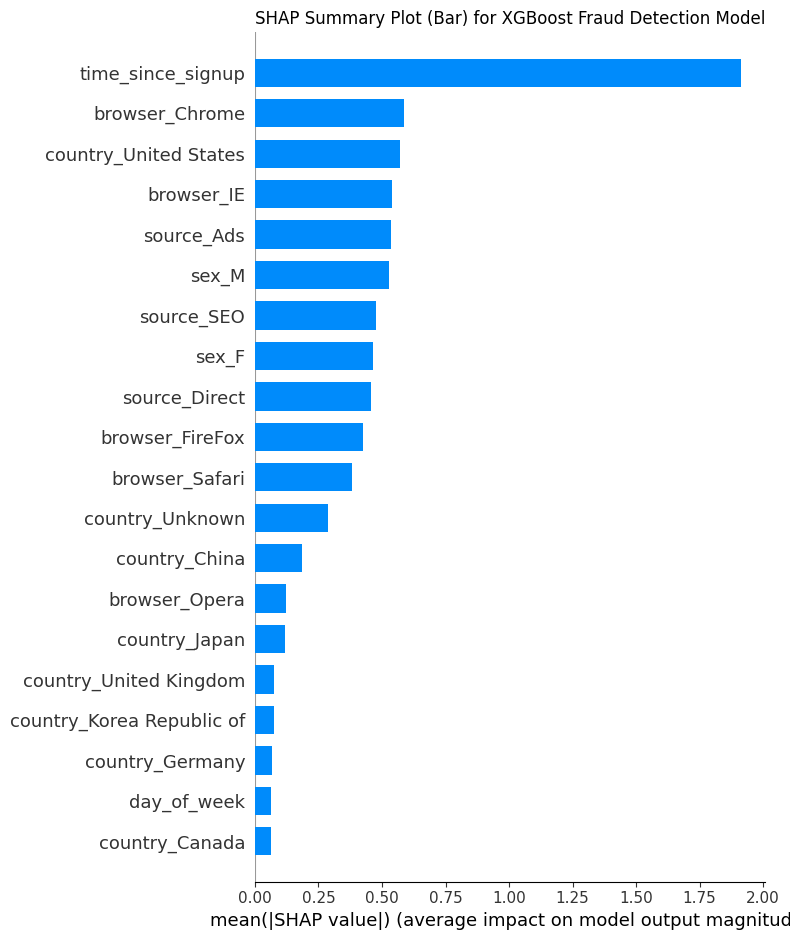

In [17]:
shap.summary_plot(shap_values, X_test_fraud_df, plot_type="bar", show=False)
plt.title("SHAP Summary Plot (Bar) for XGBoost Fraud Detection Model")
plt.tight_layout()
plt.show()

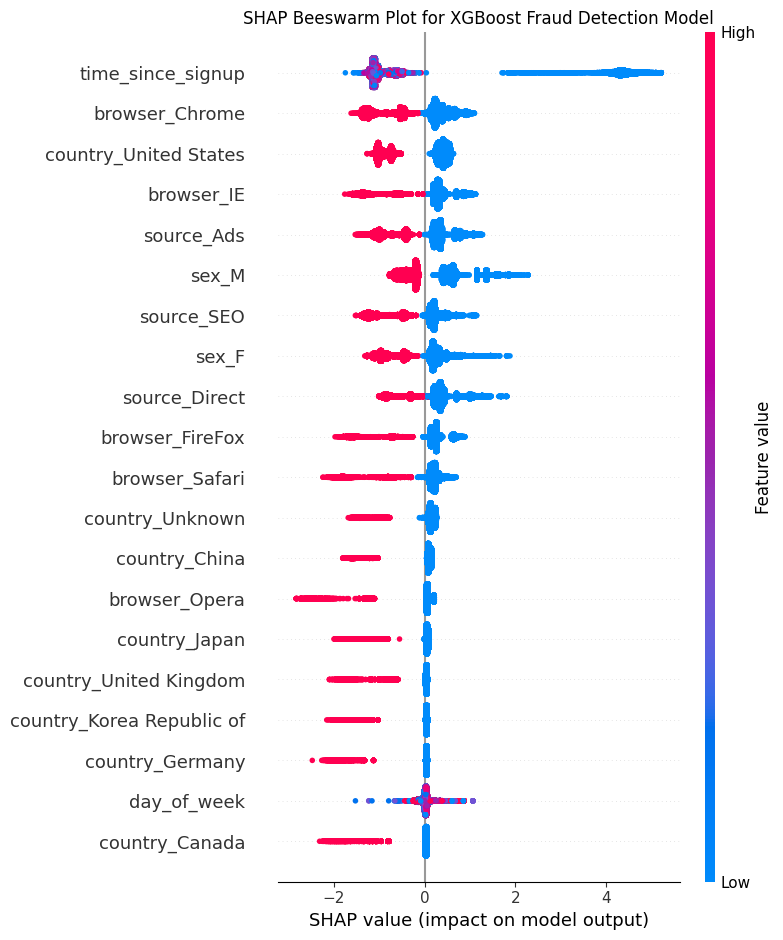

In [18]:
shap.summary_plot(shap_values, X_test_fraud_df, show=False)
plt.title("SHAP Beeswarm Plot for XGBoost Fraud Detection Model")
plt.tight_layout()
plt.show()

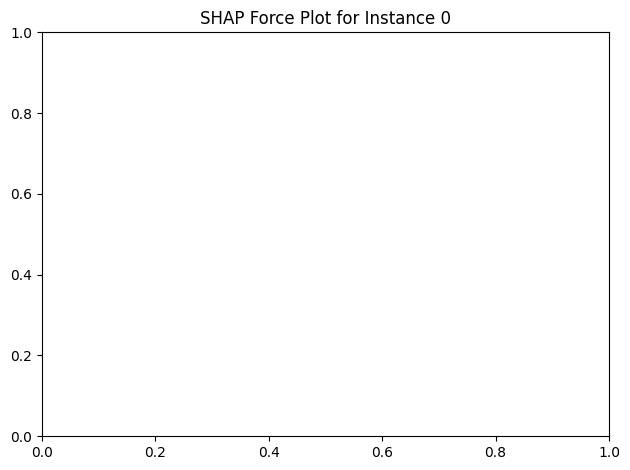

In [19]:
instance_idx = 0
shap.force_plot(explainer.expected_value, shap_values[instance_idx], X_test_fraud_df.iloc[instance_idx], show=False)
plt.title(f"SHAP Force Plot for Instance {instance_idx}")
plt.tight_layout()
plt.show()

In [20]:
shap.summary_plot(shap_values, X_test_fraud_df, plot_type="bar", show=False)
plt.title("SHAP Summary Plot (Bar) for XGBoost Fraud Detection Model")
plt.tight_layout()
plt.savefig('../figures/shap_summary_bar.png')
plt.close()

In [21]:
shap.summary_plot(shap_values, X_test_fraud_df, show=False)
plt.title("SHAP Beeswarm Plot for XGBoost Fraud Detection Model")
plt.tight_layout()
plt.savefig('../figures/shap_beeswarm.png')
plt.close()

In [22]:
shap.force_plot(explainer.expected_value, shap_values[0], X_test_fraud_df.iloc[0], show=False, matplotlib=True)
plt.title("SHAP Force Plot for Instance 0")
plt.tight_layout()
plt.savefig('../figures/shap_force_instance_0.png')
plt.close()